In [78]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

In [79]:
# CIFAR100_SUPERCLASSES="""
# cifar100-aquatic_mammals
# cifar100-fish
# cifar100-flowers
# cifar100-food_containers
# cifar100-fruit_and_vegetables
# cifar100-household_electrical_devices
# cifar100-household_furniture
# cifar100-insects
# cifar100-large_carnivores
# cifar100-large_man_made_outdoor_things
# cifar100-large_natural_outdoor_scenes
# cifar100-large_omnivores_and_herbivores
# cifar100-medium_mammals
# cifar100-non_insect_invertebrates
# cifar100-people
# cifar100-reptiles
# cifar100-small_mammals
# cifar100-trees
# cifar100-vehicles_1
# cifar100-vehicles_2
# """.strip().split("\n")

# CIFAR100_SUPERCLASSES

In [80]:
api = wandb.Api()

In [81]:
# EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run3/hyperopt"
EXPERIMENT_GROUP = "./artifacts/2023-10-s16/experiments/ex2-investigate-parameterization"

In [82]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    use_val_split,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
#             {"config.seed": {"$in": [1, 2, 3]}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                     
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )
        
#     if verbose:
#         print("Missing dataset", set(CIFAR100_SUPERCLASSES).difference(datasets))

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1id",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-attention:random--uncentered",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=9 sec). Create a new API with an integer timeout larger than 9, e.g., `api = wandb.Api(timeout=19)` to increase the graphql timeout.


we have 0 runs


KeyError: 'lambda_layer'

In [25]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1diag",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

we have 33 runs
df.shape: (11, 11)


lambda_layer   val_acc                 val_agreement                  \
                     mean       std count          mean       std count   
0      0.000000  0.480294  0.009471     3      0.479626  0.009886     3   
1      0.000001  0.502338  0.027060     3      0.501002  0.027110     3   
2      0.000010  0.501002  0.015652     3      0.499666  0.015174     3   
3      0.000100  0.486306  0.013039     3      0.486306  0.013039     3   
4      0.001000  0.488310  0.020073     3      0.488310  0.020073     3   
5      0.010000  0.476954  0.011158     3      0.475618  0.011395     3   
6      0.100000  0.472946  0.010604     3      0.472278  0.011742     3   
7      1.000000  0.466934  0.010413     3      0.466934  0.010413     3   
8     10.000000  0.459586  0.012080     3      0.459586  0.012080     3   
9    100.000000  0.446894  0.000000     3      0.446894  0.000000     3   
10  1000.000000  0.455578  0.017044     3      0.455578  0.017044     3   

   val_agreement_on_teacher_correct                 teacher_acc  
                               mean       std count        mean  
0                          0.479626  0.009886     3    0.998664  
1                          0.501002  0.027110     3    0.998664  
2                          0.499666  0.015174     3    0.998664  
3                          0.486306  0.013039     3    0.998664  
4                          0.488310  0.020073     3    0.998664  
5                          0.475618  0.011395     3    0.998664  
6                          0.472278  0.011742     3    0.998664  
7                          0.466934  0.010413     3    0.998664  
8                          0.459586  0.012080     3    0.998664  
9                          0.446894  0.000000     3    0.998664  
10                         0.455578  0.017044     3    0.998664

# Comparison on `cifar100-resnet18-v1`

experiment group: ./artifacts/2023-10-s16/experiments/ex2-investigate-parameterization
date: 2023-10-05 17:10:33.737766


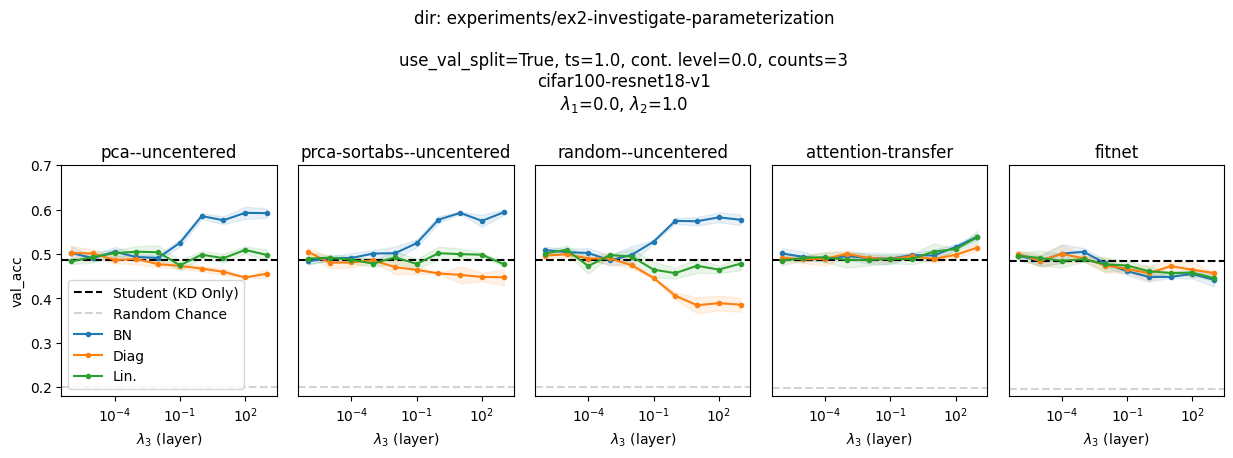

In [77]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(student):
    alias_dict = dict(
        resnet18xscifarcompr1="BN",
        resnet18xscifarcompr1diag="Diag",
        resnet18xscifarcompr1lin="Lin."
    )
    
    return alias_dict.get(student, student)
    
    
def viz_distillation(
    teacher, arr_students, policies,
    show_legend=True,
):
    contamination_level = 0.0
    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    ncols = len(policies)
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(policy.replace("basis-identity:", ""))
        
        for six, student in enumerate(arr_students):

            df = read_data(
                teacher=teacher,
                student=student,
                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                contamination_level=contamination_level,
                use_val_split=use_val_split,
                verbose=False
            )


            with nullcontext(enter_result="sanity check"):            
                if count == None:

                    np.testing.assert_equal(
                        df[col]["count"].values,
                        df[col]["count"].values[0]
                    )

                    count = df[col]["count"].values[0]
                else:
                    np.testing.assert_equal(df[col]["count"].values, count)  
                    pass 

                if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                    or df[col]["count"].values[0] != count:
                        print(f"[warning] policy={policy}:", df[col]["count"].values)    

                    
            if six == 0:


#                 plt.axhline(
#                     df["teacher_acc"].values[-1],
#                     ls="-",
#                     color="k",
#                     label="Teacher"
#                 )

                if pix > 0:
                    np.testing.assert_allclose(
                        acc_student_kd_only,
                        df[col]["mean"].values[0],
                        atol=1e-2
                    )
                else:
                    acc_student_kd_only = df[col]["mean"].values[0]

                plt.axhline(
                    acc_student_kd_only,
                    ls="--",
                    color="k",
                    label="Student (KD Only)"
                )

                plt.axhline(0.2, ls="--", color="lightgray", label="Random Chance")

            # here, we use [1:] to excluding lambda_layer=0
            assert df["lambda_layer"][0] == 0.0
            ticks = df["lambda_layer"][1:]
            mean = df[col]["mean"][1:]
            stderr = df[col]["std"][1:] / (count ** 0.5)

            best_k = np.argmax(df[col]["mean"])
            best_lambda_layer = df["lambda_layer"][best_k]

            sorted_indices = np.argsort(-mean.values)


            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(student)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.1,
                color=plt.gca().lines[-1].get_color()
            )


            plt.xscale("log")
            plt.xlabel("$\lambda_3$ (layer)")
            plt.ylabel(col)

        plt.ylim(top=0.7)
        if pix == 0:
            plt.legend()

        if pix % ncols != 0:
            plt.ylabel("")
            plt.yticks([])

    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    arr_students=[
        "resnet18xscifarcompr1",
        "resnet18xscifarcompr1diag",
        "resnet18xscifarcompr1lin",
    ],
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        f"basis-identity:random--uncentered",
#         "vid",
        "attention-transfer",
        "fitnet",
    ],
)

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^6\}$.

Denote the feature from the student model as $\boldsymbol h = g(\boldsymbol a )$ where $g$ is a transformation with also involving in the student model

$$
\boldsymbol{a}^{(l+1)} = (\phi^{l+1} \circ g) (\boldsymbol a)
$$.

We have *3 parameterizations* of the function $g$, namely
- batch norm: $g_i = \alpha \bigg( \frac{a_i - \mu_i}{\sigma_i} \bigg)  \beta$ 
- diagonal: $g_i = w_i a_i + b_i$ 
- linear: $g = W\boldsymbol a  +\boldsymbol b$


*Aims:* 
- investigate the effect of the student parameterization on the distillation effficient.

*Conclusion:*
- Generally, the batchnorm parameterization performs the best.
- For the best value of $\lambda_3$, the `diagonal` and `linear` parameterizations still underperform the `batchnorm` parameterization.